In [4]:
!pip install kaggle

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
! chmod 600 /root/.kaggle/kaggle.json

In [7]:
! kaggle competitions download Walmart-Recruiting-Store-Sales-Forecasting

100% 2.70M/2.70M [00:00<00:00, 184MB/s]



In [8]:
! unzip Walmart-Recruiting-Store-Sales-Forecasting.zip

Archive:  Walmart-Recruiting-Store-Sales-Forecasting.zip
  inflating: features.csv.zip        
  inflating: sampleSubmission.csv.zip  
  inflating: stores.csv              
  inflating: test.csv.zip            
  inflating: train.csv.zip           


In [9]:
! unzip train.csv.zip

Archive:  train.csv.zip
  inflating: train.csv               


In [10]:
! unzip test.csv.zip

Archive:  test.csv.zip
  inflating: test.csv                


In [11]:
! unzip features.csv.zip

Archive:  features.csv.zip
  inflating: features.csv            


In [12]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.feature_selection import mutual_info_regression

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:,.4f}".format)
plt.rcParams["figure.dpi"] = 110

# EDA

In [13]:
SUPERBOWL_DATES = pd.to_datetime([
    "2010-02-12", "2011-02-11", "2012-02-10", "2013-02-08"
])
LABORDAY_DATES = pd.to_datetime([
    "2010-09-10", "2011-09-09", "2012-09-07", "2013-09-06"
])
THANKSGIVING_DATES = pd.to_datetime([
    "2010-11-26", "2011-11-25", "2012-11-23", "2013-11-29"
])
CHRISTMAS_DATES = pd.to_datetime([
    "2010-12-31", "2011-12-30", "2012-12-28", "2013-12-27"
])

# Additional important dates
BACK_TO_SCHOOL_DATES = pd.to_datetime([
    "2010-08-27", "2011-08-26", "2012-08-31"
])
EASTER_DATES = pd.to_datetime([
    "2010-04-02", "2011-04-22", "2012-04-06"
])

In [14]:
class TimeSeriesFeatureBuilder:

    def __init__(
        self,
        lags: list            = [1, 2, 3, 4, 13, 26, 52],   # added: 2, 3 (near-term), 13 (quarter), 26 (half-year)
        rolling_windows: list = [4, 12, 26, 52],
        group_cols: list      = ["Store", "Dept"],
        target_col: str       = "Weekly_Sales",
    ):
        self.lags            = lags
        self.rolling_windows = rolling_windows
        self.group_cols      = group_cols
        self.target_col      = target_col

    def fit_transform(self, df: pd.DataFrame) -> pd.DataFrame:
        """Run on the FULL merged dataframe before any train/val split."""
        df = df.copy()
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.sort_values(self.group_cols + ["Date"]).reset_index(drop=True)

        grp = df.groupby(self.group_cols)[self.target_col]

        # Lag features: what were sales N weeks ago?
        for lag in self.lags:
            df[f"sales_lag_{lag}"] = grp.shift(lag)

        # Rolling mean + std — shift(1) prevents leaking the current week
        shifted = grp.shift(1)
        for w in self.rolling_windows:
            df[f"rolling_mean_{w}"] = shifted.transform(
                lambda x: x.rolling(w, min_periods=1).mean()
            )
            df[f"rolling_std_{w}"] = shifted.transform(
                lambda x: x.rolling(w, min_periods=1).std()
            )
            # min/max: range of sales over the window
            df[f"rolling_min_{w}"] = shifted.transform(
                lambda x: x.rolling(w, min_periods=1).min()
            )
            df[f"rolling_max_{w}"] = shifted.transform(
                lambda x: x.rolling(w, min_periods=1).max()
            )
            # median: robust to outlier holiday spikes
            df[f"rolling_median_{w}"] = shifted.transform(
                lambda x: x.rolling(w, min_periods=1).median()
            )
            # skew: detects asymmetric distributions (holiday spikes push right)
            df[f"rolling_skew_{w}"] = shifted.transform(
                lambda x: x.rolling(w, min_periods=2).skew()
            )

        # Coefficient of Variation — relative volatility, scale-independent
        df["rolling_cv_4"] = (
            df["rolling_std_4"] / df["rolling_mean_4"].replace(0, np.nan)
        )

        # Momentum — short-term vs long-term trend ratio: >1 means accelerating
        df["sales_momentum"] = (
            df["rolling_mean_4"] / df["rolling_mean_52"].replace(0, np.nan)
        )

        # EWMA: weights recent weeks more than plain rolling mean
        df["ewma_4"]  = shifted.transform(lambda x: x.ewm(span=4,  min_periods=1).mean())
        df["ewma_12"] = shifted.transform(lambda x: x.ewm(span=12, min_periods=1).mean())

        # YoY: removes long-term trend, improves stationarity
        if 52 in self.lags:
            df["yoy_diff"]        = df[self.target_col] - df["sales_lag_52"]
            df["yoy_growth_rate"] = (
                df[self.target_col] / df["sales_lag_52"].replace(0, np.nan) - 1
            )

        # Days since last markdown event (per store, not per dept)
        md_cols = [c for c in
                   ["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]
                   if c in df.columns]
        if md_cols:
            df["_any_md"] = df[md_cols].notna().any(axis=1)
            df["days_since_markdown"] = (
                df.groupby("Store")["_any_md"]
                .transform(lambda x:
                    x.cumsum().where(x).ffill().rsub(x.cumsum()).mul(7)
                )
            )
            df.drop(columns=["_any_md"], inplace=True)

        # External temporal features — require sorted history, so computed here
        if "Fuel_Price" in df.columns:
            fp_prev = df.groupby("Store")["Fuel_Price"].shift(1)
            df["fuel_price_chg"]     = df["Fuel_Price"] - fp_prev
            df["fuel_price_chg_pct"] = df["fuel_price_chg"] / fp_prev.replace(0, np.nan)

        if "CPI" in df.columns:
            cpi_52 = df.groupby("Store")["CPI"].shift(52)
            df["cpi_yoy"] = df["CPI"] / cpi_52.replace(0, np.nan) - 1

        if "Unemployment" in df.columns:
            df["unemp_delta"] = (
                df["Unemployment"] - df.groupby("Store")["Unemployment"].shift(4)
            )

        self._fitted = True
        return df

    def transform_incremental(
        self, df_history: pd.DataFrame, df_new: pd.DataFrame
    ) -> pd.DataFrame:
        """
        Inference only: appends new week(s) to history, computes time
        features, returns only the new rows.
        """
        if not hasattr(self, "_fitted"):
            raise RuntimeError("Call fit_transform on full data first.")
        time_prefixes = [
            "sales_lag", "rolling_", "ewma_", "yoy_", "days_since",
            "fuel_price_", "cpi_yoy", "unemp_delta", "sales_momentum",
        ]
        time_cols = [c for c in df_history.columns
                     if any(c.startswith(p) for p in time_prefixes)]
        combined    = pd.concat(
            [df_history.drop(columns=time_cols, errors="ignore"), df_new],
            ignore_index=True,
        )
        combined_fe = self.fit_transform(combined)
        return combined_fe.iloc[-len(df_new):].reset_index(drop=True)

In [15]:
class CalendarFeatureTransformer(BaseEstimator, TransformerMixin):
    """
    Extracts week, month, quarter from Date.
    Adds sin/cos cyclical encodings so week 52 → week 1 is a small step.
    Adds binary flags for each specific holiday and proximity features
    (weeks_to_thanksgiving, pre_thanksgiving, pre_christmas, is_january).
    Added: is_payweek, is_black_friday, is_post_thanksgiving,
           is_post_christmas, is_tax_refund_season, is_summer.
    """

    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()
        X["Date"] = pd.to_datetime(X["Date"])

        X["week"]          = X["Date"].dt.isocalendar().week.astype(int)
        X["month"]         = X["Date"].dt.month
        X["year"]          = X["Date"].dt.year
        X["quarter"]       = X["Date"].dt.quarter
        X["week_of_month"] = (X["Date"].dt.day - 1) // 7 + 1

        # Cyclical: prevents the model treating week 52 → week 1 as a big jump
        X["week_sin"]  = np.sin(2 * np.pi * X["week"]  / 52)
        X["week_cos"]  = np.cos(2 * np.pi * X["week"]  / 52)
        X["month_sin"] = np.sin(2 * np.pi * X["month"] / 12)
        X["month_cos"] = np.cos(2 * np.pi * X["month"] / 12)

        # Which specific holiday is this week?
        X["is_superbowl"]      = X["Date"].isin(SUPERBOWL_DATES).astype(int)
        X["is_laborday"]       = X["Date"].isin(LABORDAY_DATES).astype(int)
        X["is_thanksgiving"]   = X["Date"].isin(THANKSGIVING_DATES).astype(int)
        X["is_christmas"]      = X["Date"].isin(CHRISTMAS_DATES).astype(int)
        X["is_back_to_school"] = X["Date"].isin(BACK_TO_SCHOOL_DATES).astype(int)
        X["is_easter"]         = X["Date"].isin(EASTER_DATES).astype(int)

        def weeks_to_nearest(dates_series, holiday_dates):
            return [
                min([(d - h).days // 7 for h in holiday_dates], key=abs)
                for d in dates_series
            ]

        X["weeks_to_thanksgiving"] = np.clip(
            weeks_to_nearest(X["Date"], THANKSGIVING_DATES), -8, 8
        )
        X["weeks_to_christmas"] = np.clip(
            weeks_to_nearest(X["Date"], CHRISTMAS_DATES), -8, 8
        )
        X["pre_thanksgiving"] = X["weeks_to_thanksgiving"].between(-4, -1).astype(int)
        X["pre_christmas"]    = X["weeks_to_christmas"].between(-4, -1).astype(int)
        X["is_january"]       = (X["month"] == 1).astype(int)

        # Pay period: customers tend to shop when they receive their paycheck
        X["is_payweek"] = (
            (X["Date"].dt.day <= 7) | X["Date"].dt.day.between(14, 21)
        ).astype(int)

        # Black Friday: the week immediately after Thanksgiving — peak sales
        X["is_black_friday"] = (X["weeks_to_thanksgiving"] == 1).astype(int)

        # Post-Thanksgiving hangover: 1-2 weeks after, demand drops back
        X["is_post_thanksgiving"] = X["weeks_to_thanksgiving"].between(1, 2).astype(int)

        # Post-Christmas: early January sees returns and markdown clearance
        X["is_post_christmas"] = (
            (X["month"] == 1) & (X["Date"].dt.day <= 14)
        ).astype(int)

        # Tax refund season: Feb-Mar IRS refunds give consumers extra spending power
        X["is_tax_refund_season"] = X["month"].isin([2, 3]).astype(int)

        # Summer months: Jun-Aug — seasonal categories shift (outdoor, back-to-school prep)
        X["is_summer"] = X["month"].isin([6, 7, 8]).astype(int)

        return X

In [16]:
class MarkdownFeatureTransformer(BaseEstimator, TransformerMixin):
    """
    MarkDown1..5 are ~66% null because promotions don't run every week.
    Aggregates them into summary columns:
      total_markdown     — total promotional spend this week
      markdown_active    — binary: was any promotion running?
      markdown_count     — how many of the 5 types were active?
      max_single_md      — size of the largest single discount
      total_markdown_log — log-scaled total (corrects right skew)
      markdown_diversity — fraction of types active (count / 5)
      md{i}_active       — per-type binary flags (each type has different mechanism)
    """

    def __init__(self, drop_raw: bool = True):
        self.drop_raw = drop_raw

    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X   = X.copy()
        mdc = [c for c in ["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]
               if c in X.columns]
        if not mdc:
            return X
        md = X[mdc].fillna(0)

        X["total_markdown"]     = md.sum(axis=1)
        X["markdown_active"]    = (X["total_markdown"] > 0).astype(int)
        X["markdown_count"]     = (md > 0).sum(axis=1)
        X["max_single_md"]      = md.max(axis=1)
        X["total_markdown_log"] = np.log1p(X["total_markdown"].values.astype(float))

        # Fraction of markdown types that are active: 0.0 (none) – 1.0 (all five)
        X["markdown_diversity"] = X["markdown_count"] / len(mdc)

        # Per-type presence flags — each MarkDown type covers a different promotion channel
        for col in mdc:
            flag_name = col.lower().replace("markdown", "md") + "_active"
            X[flag_name] = (X[col].fillna(0) > 0).astype(int)

        if self.drop_raw:
            X.drop(columns=mdc, inplace=True)
        return X

In [17]:
class StoreFeatureTransformer(BaseEstimator, TransformerMixin):
    """
    Derives features from Type (A/B/C) and Size (sq footage).
    Computes dept_sales_share: each department's historical fraction
    of its store's total sales — fitted on train only, no leakage.
    Unseen (Store, Dept) pairs at inference fall back to training mean.
    Added: dept_volatility_cv, dept_rank_in_store, store_holiday_sensitivity.
    """

    def fit(self, X: pd.DataFrame, y=None):
        self.fitted_ = True
        if "Weekly_Sales" in X.columns:
            store_avg        = X.groupby("Store")["Weekly_Sales"].mean()
            dept_avg         = X.groupby(["Store", "Dept"])["Weekly_Sales"].mean()
            self.dept_share_ = (dept_avg / store_avg).rename("dept_sales_share")

            # Dept volatility: CV = std/mean — how erratic is this dept vs its own average?
            dept_std = X.groupby(["Store", "Dept"])["Weekly_Sales"].std()
            self.dept_volatility_ = (
                dept_std / dept_avg.replace(0, np.nan)
            ).rename("dept_volatility_cv")

            # Dept rank within its store by average sales (1 = top revenue dept)
            self.dept_rank_ = (
                dept_avg
                .groupby(level="Store")
                .rank(ascending=False, method="min")
                .rename("dept_rank_in_store")
            )

            # Store-level holiday sensitivity: ratio of mean holiday vs non-holiday sales
            if "IsHoliday" in X.columns:
                hol_avg  = X[X["IsHoliday"] == 1].groupby("Store")["Weekly_Sales"].mean()
                nhol_avg = X[X["IsHoliday"] == 0].groupby("Store")["Weekly_Sales"].mean()
                self.store_holiday_sensitivity_ = (
                    hol_avg / nhol_avg.replace(0, np.nan)
                ).rename("store_holiday_sensitivity")
            else:
                self.store_holiday_sensitivity_ = None
        else:
            self.dept_share_                = None
            self.dept_volatility_           = None
            self.dept_rank_                 = None
            self.store_holiday_sensitivity_ = None
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()
        if "Size" in X.columns:
            X["store_size_log"] = np.log1p(X["Size"])
        if "Type" in X.columns:
            X["store_type_ord"] = (
                X["Type"].map({"A": 2, "B": 1, "C": 0}).fillna(-1).astype(int)
            )
        if self.dept_share_ is not None:
            X = X.join(self.dept_share_, on=["Store", "Dept"], how="left")
            X["dept_sales_share"] = X["dept_sales_share"].fillna(self.dept_share_.mean())

        if self.dept_volatility_ is not None:
            X = X.join(self.dept_volatility_, on=["Store", "Dept"], how="left")
            X["dept_volatility_cv"] = X["dept_volatility_cv"].fillna(self.dept_volatility_.mean())

        if self.dept_rank_ is not None:
            X = X.join(self.dept_rank_, on=["Store", "Dept"], how="left")
            X["dept_rank_in_store"] = X["dept_rank_in_store"].fillna(self.dept_rank_.max())

        if self.store_holiday_sensitivity_ is not None:
            X = X.join(self.store_holiday_sensitivity_, on="Store", how="left")
            X["store_holiday_sensitivity"] = X["store_holiday_sensitivity"].fillna(
                self.store_holiday_sensitivity_.mean()
            )

        return X

In [18]:
class ExternalFeatureTransformer(BaseEstimator, TransformerMixin):
    """
    Handles Temperature, Fuel_Price, CPI, Unemployment.
    Fills rare nulls with training medians (fitted, no leakage).
    Adds temp_bucket: 0=cold / 1=mild / 2=warm / 3=hot.
    Added: is_extreme_cold (<=20°F), is_extreme_heat (>=90°F).
    Note: temporal external features (fuel_price_chg, cpi_yoy, unemp_delta)
          are computed in TimeSeriesFeatureBuilder since they require shift().
    """

    def fit(self, X: pd.DataFrame, y=None):
        self.fitted_  = True
        self.ext_cols_ = [c for c in ["Temperature","Fuel_Price","CPI","Unemployment"]
                          if c in X.columns]
        self.medians_  = X[self.ext_cols_].median()
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()
        for col in self.ext_cols_:
            X[col] = X[col].fillna(self.medians_[col])
        if "Temperature" in X.columns:
            X["temp_bucket"] = pd.cut(
                X["Temperature"],
                bins=[-999, 32, 60, 80, 999],
                labels=[0, 1, 2, 3],
            ).astype(float)
            # Extreme weather reduces foot traffic regardless of season bucket
            X["is_extreme_cold"] = (X["Temperature"] <= 20).astype(int)
            X["is_extreme_heat"] = (X["Temperature"] >= 90).astype(int)
        return X

In [19]:
class DropColumnsTransformer(BaseEstimator, TransformerMixin):
    """
    Drops raw columns superseded by engineered ones,
    plus the target and the Date string.
    """

    def __init__(self, cols_to_drop: list = None):
        self.cols_to_drop = cols_to_drop or ["Date", "Type", "Size", "Weekly_Sales"]

    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        return X.drop(columns=[c for c in self.cols_to_drop if c in X.columns])


def build_feature_pipeline(drop_raw_markdowns: bool = True) -> Pipeline:
    """Assembles the five row-independent transformers into a single sklearn Pipeline."""
    return Pipeline(steps=[
        ("calendar",  CalendarFeatureTransformer()),
        ("markdown",  MarkdownFeatureTransformer(drop_raw=drop_raw_markdowns)),
        ("store",     StoreFeatureTransformer()),
        ("external",  ExternalFeatureTransformer()),
        ("drop_cols", DropColumnsTransformer()),
    ])

# Feature Selection Functions

In [20]:
def _compute_iv_for_feature(
    feature_values: np.ndarray,
    target_bins: np.ndarray,
    n_target_bins: int,
    n_feature_bins: int = 10,
    feature_is_binary: bool = False,
) -> tuple:
    """
    Bins a feature then computes WOE and IV against a pre-binned target.
    Returns (total_iv: float, detail_table: DataFrame).
    The 'event' is defined as landing in the top sales decile.
    """
    if feature_is_binary or len(np.unique(feature_values)) <= 2:
        feature_bins = feature_values.astype(int)
    else:
        kbd = KBinsDiscretizer(n_bins=n_feature_bins, encode="ordinal", strategy="quantile")
        try:
            feature_bins = kbd.fit_transform(
                feature_values.reshape(-1, 1)
            ).ravel().astype(int)
        except Exception:
            feature_bins = (
                pd.qcut(feature_values,
                        q=min(n_feature_bins, len(np.unique(feature_values))),
                        labels=False, duplicates="drop")
                .astype(float).fillna(0).astype(int).values
            )

    event_bin    = n_target_bins - 1
    is_event     = (target_bins == event_bin).astype(int)
    total_events = is_event.sum()
    total_non    = len(is_event) - total_events
    if total_events == 0 or total_non == 0:
        return 0.0, pd.DataFrame()

    rows = []
    for bucket in np.unique(feature_bins):
        mask  = feature_bins == bucket
        n_ev  = is_event[mask].sum()
        n_no  = (~is_event[mask].astype(bool)).sum()
        d_ev  = (n_ev + 0.5) / (total_events + 0.5)  # Laplace smoothing
        d_no  = (n_no + 0.5) / (total_non   + 0.5)
        woe   = np.log(d_ev / d_no)
        rows.append({"bucket": bucket, "n_event": n_ev, "n_non": n_no,
                     "woe": woe, "iv": (d_ev - d_no) * woe})

    table = pd.DataFrame(rows)
    return float(table["iv"].sum()), table

In [21]:
class WOEIVFilter(BaseEstimator, TransformerMixin):
    """
    Bins the continuous target into quantile deciles, computes Information
    Value for every feature, drops features below iv_threshold.

    IV thresholds (standard credit-scoring convention):
      < 0.02   — useless
      0.02–0.1 — weak
      0.1–0.3  — medium
      > 0.3    — strong
    """

    def __init__(self, iv_threshold=0.02, n_target_bins=10, n_feature_bins=10):
        self.iv_threshold   = iv_threshold
        self.n_target_bins  = n_target_bins
        self.n_feature_bins = n_feature_bins

    def fit(self, X: pd.DataFrame, y: np.ndarray):
        self.fitted_           = True
        self.feature_names_in_ = list(X.columns)

        target_kbd  = KBinsDiscretizer(
            n_bins=self.n_target_bins, encode="ordinal", strategy="quantile"
        )
        target_bins = target_kbd.fit_transform(
            np.clip(np.array(y), 0, None).reshape(-1, 1)
        ).ravel().astype(int)

        iv_scores, self.iv_tables_ = {}, {}
        for col in X.columns:
            vals      = X[col].fillna(0).values.astype(float)
            is_binary = set(np.unique(vals)).issubset({0.0, 1.0})
            iv, tbl   = _compute_iv_for_feature(
                vals, target_bins,
                n_target_bins=self.n_target_bins,
                n_feature_bins=self.n_feature_bins,
                feature_is_binary=is_binary,
            )
            iv_scores[col]       = iv
            self.iv_tables_[col] = tbl

        self.iv_scores_         = pd.Series(iv_scores).sort_values(ascending=False)
        self.selected_features_ = list(self.iv_scores_[self.iv_scores_ >= self.iv_threshold].index)
        self.dropped_features_  = list(self.iv_scores_[self.iv_scores_ <  self.iv_threshold].index)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        missing = [c for c in self.selected_features_ if c not in X.columns]
        if missing:
            raise ValueError(f"Missing columns: {missing}")
        return X[self.selected_features_].copy()

    @property
    def iv_summary(self) -> pd.DataFrame:
        df = self.iv_scores_.reset_index()
        df.columns = ["feature", "iv"]
        df["strength"] = pd.cut(df["iv"],
            bins=[-np.inf, 0.02, 0.1, 0.3, np.inf],
            labels=["useless", "weak", "medium", "strong"])
        df["kept"] = df["iv"] >= self.iv_threshold
        return df

In [22]:
class MutualInfoFilter(BaseEstimator, TransformerMixin):
    """
    Computes mutual information between each feature and the continuous
    target — the proper regression-native alternative to IV.
    Drops features whose MI < mi_threshold * max(MI scores).

    mi_threshold=0.05 means: keep features that carry at least 5%
    of the information the strongest feature carries.
    """

    def __init__(self, mi_threshold=0.05, random_state=42):
        self.mi_threshold = mi_threshold
        self.random_state = random_state

    def fit(self, X: pd.DataFrame, y: np.ndarray):
        self.fitted_           = True
        self.feature_names_in_ = list(X.columns)

        mi_raw          = mutual_info_regression(
            X.fillna(0), y, random_state=self.random_state
        )
        self.mi_scores_ = pd.Series(mi_raw, index=X.columns).sort_values(ascending=False)

        cutoff                  = self.mi_scores_.max() * self.mi_threshold
        self.selected_features_ = list(self.mi_scores_[self.mi_scores_ >= cutoff].index)
        self.dropped_features_  = list(self.mi_scores_[self.mi_scores_ <  cutoff].index)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        return X[[c for c in self.selected_features_ if c in X.columns]].copy()

In [23]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    """
    Removes one of any pair of features with |Pearson r| >= corr_threshold.
    When a pair conflicts, the feature with the lower importance score
    is dropped (importance comes from IV scores by default).
    """

    def __init__(self, corr_threshold=0.90, importance: pd.Series = None):
        self.corr_threshold = corr_threshold
        self.importance     = importance

    def fit(self, X: pd.DataFrame, y=None):
        self.fitted_           = True
        self.feature_names_in_ = list(X.columns)
        self.corr_matrix_      = X.fillna(0).corr().abs()

        importance = (
            self.importance.reindex(X.columns).fillna(0)
            if self.importance is not None
            else pd.Series(range(len(X.columns), 0, -1), index=X.columns, dtype=float)
        )

        to_drop = set()
        cols = list(X.columns)
        for i in range(len(cols)):
            for j in range(i + 1, len(cols)):
                ci, cj = cols[i], cols[j]
                if ci in to_drop or cj in to_drop:
                    continue
                if self.corr_matrix_.loc[ci, cj] >= self.corr_threshold:
                    to_drop.add(cj if importance.get(ci, 0) >= importance.get(cj, 0) else ci)

        self.dropped_features_  = sorted(to_drop)
        self.selected_features_ = [c for c in cols if c not in to_drop]
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        return X[[c for c in self.selected_features_ if c in X.columns]].copy()

    def correlated_pairs(self) -> pd.DataFrame:
        rows = []
        cols = self.feature_names_in_
        for i in range(len(cols)):
            for j in range(i + 1, len(cols)):
                r = self.corr_matrix_.loc[cols[i], cols[j]]
                if r >= self.corr_threshold:
                    dropped = cols[i] if cols[i] in self.dropped_features_ else cols[j]
                    rows.append({"feature_a": cols[i], "feature_b": cols[j],
                                 "correlation": round(r, 4),
                                 "kept":    cols[j] if dropped == cols[i] else cols[i],
                                 "dropped": dropped})
        return pd.DataFrame(rows).sort_values("correlation", ascending=False)

In [24]:
class FeatureSelector(BaseEstimator, TransformerMixin):
    """
    Chains WOEIVFilter → MutualInfoFilter → CorrelationFilter.
    Each filter receives only the features that survived the previous one.
    The correlation filter uses IV scores as its importance ranking.
    """

    def __init__(
        self,
        iv_threshold:   float = 0.02,
        mi_threshold:   float = 0.05,
        corr_threshold: float = 0.90,
        n_target_bins:  int   = 10,
        n_feature_bins: int   = 10,
        run_iv:   bool = True,
        run_mi:   bool = True,
        run_corr: bool = True,
    ):
        self.iv_threshold   = iv_threshold
        self.mi_threshold   = mi_threshold
        self.corr_threshold = corr_threshold
        self.n_target_bins  = n_target_bins
        self.n_feature_bins = n_feature_bins
        self.run_iv         = run_iv
        self.run_mi         = run_mi
        self.run_corr       = run_corr

    def fit(self, X: pd.DataFrame, y: np.ndarray):
        self.fitted_           = True
        self.initial_features_ = list(X.columns)
        X_curr = X.copy()
        y      = np.array(y)

        self.iv_filter_ = None
        if self.run_iv:
            self.iv_filter_ = WOEIVFilter(
                self.iv_threshold, self.n_target_bins, self.n_feature_bins
            )
            self.iv_filter_.fit(X_curr, y)
            X_curr = self.iv_filter_.transform(X_curr)
            print(f"[IV filter]   {len(self.initial_features_):3d} → {len(X_curr.columns):3d}  "
                  f"dropped: {self.iv_filter_.dropped_features_}")

        self.mi_filter_ = None
        if self.run_mi:
            self.mi_filter_ = MutualInfoFilter(self.mi_threshold)
            self.mi_filter_.fit(X_curr, y)
            X_curr = self.mi_filter_.transform(X_curr)
            print(f"[MI filter]       → {len(X_curr.columns):3d}  "
                  f"dropped: {self.mi_filter_.dropped_features_}")

        self.corr_filter_ = None
        if self.run_corr:
            importance = (
                self.iv_filter_.iv_scores_ if self.iv_filter_ is not None else
                self.mi_filter_.mi_scores_ if self.mi_filter_ is not None else None
            )
            self.corr_filter_ = CorrelationFilter(self.corr_threshold, importance)
            self.corr_filter_.fit(X_curr)
            X_curr = self.corr_filter_.transform(X_curr)
            print(f"[Corr filter]     → {len(X_curr.columns):3d}  "
                  f"dropped: {self.corr_filter_.dropped_features_}")

        self.selected_features_ = list(X_curr.columns)
        print(f"Result: {len(self.initial_features_)} → {len(self.selected_features_)} features kept")
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X_curr = X.copy()
        if self.iv_filter_:   X_curr = self.iv_filter_.transform(X_curr)
        if self.mi_filter_:   X_curr = self.mi_filter_.transform(X_curr)
        if self.corr_filter_: X_curr = self.corr_filter_.transform(X_curr)
        return X_curr

    def summary(self) -> pd.DataFrame:
        rows = []
        for feat in self.initial_features_:
            iv = self.iv_filter_.iv_scores_.get(feat, np.nan) if self.iv_filter_ else np.nan
            mi = self.mi_filter_.mi_scores_.get(feat, np.nan) if self.mi_filter_ else np.nan
            if feat not in self.selected_features_:
                if self.iv_filter_     and feat in self.iv_filter_.dropped_features_:   by = "IV"
                elif self.mi_filter_   and feat in self.mi_filter_.dropped_features_:   by = "MI"
                elif self.corr_filter_ and feat in self.corr_filter_.dropped_features_: by = "Corr"
                else: by = "unknown"
            else:
                by = None
            rows.append({"feature": feat,
                         "iv": round(iv, 4) if not np.isnan(iv) else np.nan,
                         "mi": round(mi, 4) if not np.isnan(mi) else np.nan,
                         "kept": feat in self.selected_features_,
                         "dropped_by": by})
        return (pd.DataFrame(rows)
                .sort_values(["kept", "iv"], ascending=[False, False])
                .reset_index(drop=True))

# Helper Functions

In [25]:
def wmae(y_true: np.ndarray, y_pred: np.ndarray, weights: np.ndarray) -> float:
    """
    Weighted Mean Absolute Error — the Walmart competition metric.
    Holiday weeks carry weight=5, non-holiday weeks weight=1.
    """
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)


def make_holiday_weights(is_holiday: pd.Series) -> np.ndarray:
    """Convert IsHoliday boolean series to a WMAE weight array (5.0 or 1.0)."""
    return np.where(is_holiday.values, 5.0, 1.0)


def predict_new_week(
    df_history: pd.DataFrame,
    df_new_week: pd.DataFrame,
    builder: TimeSeriesFeatureBuilder,
    feature_pipeline: Pipeline,
    selector: FeatureSelector,
    model,
) -> np.ndarray:
    """
    End-to-end inference on a new unseen week.
    Uses the already-fitted builder, pipeline, and selector — no re-fitting.
    """
    df_fe = builder.transform_incremental(df_history, df_new_week)
    X_new = feature_pipeline.transform(df_fe)
    X_sel = selector.transform(X_new)
    return model.predict(X_sel.values)


def plot_iv(iv_filter: WOEIVFilter, threshold: float) -> None:
    """Horizontal bar chart of IV scores, colour-coded by strength tier."""
    iv_df = iv_filter.iv_summary.sort_values("iv", ascending=True)
    color_map = {
        "useless": "#d9534f", "weak": "#f0ad4e",
        "medium":  "#5bc0de", "strong": "#5cb85c",
    }
    colors = [color_map[str(s)] for s in iv_df["strength"]]

    fig, ax = plt.subplots(figsize=(8, max(4, len(iv_df) * 0.28)))
    ax.barh(iv_df["feature"], iv_df["iv"], color=colors, edgecolor="none", height=0.7)
    ax.axvline(threshold, color="red", lw=1.2, ls="--", label=f"threshold = {threshold}")

    from matplotlib.patches import Patch
    legend_els = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
    legend_els.append(plt.Line2D([0],[0], color="red", ls="--",
                                 label=f"threshold = {threshold}"))
    ax.legend(handles=legend_els, fontsize=8, loc="lower right")
    ax.set_xlabel("Information Value (IV)")
    ax.set_title("Feature IV scores")
    plt.tight_layout()
    plt.show()


def plot_mi(mi_filter: MutualInfoFilter, threshold_frac: float) -> None:
    """Horizontal bar chart of MI scores."""
    mi_df  = mi_filter.mi_scores_.reset_index()
    mi_df.columns = ["feature", "mi"]
    mi_df  = mi_df.sort_values("mi", ascending=True)
    cutoff = mi_filter.mi_scores_.max() * threshold_frac
    colors = ["#5cb85c" if v >= cutoff else "#d9534f" for v in mi_df["mi"]]

    fig, ax = plt.subplots(figsize=(8, max(4, len(mi_df) * 0.28)))
    ax.barh(mi_df["feature"], mi_df["mi"], color=colors, edgecolor="none", height=0.7)
    ax.axvline(cutoff, color="red", lw=1.2, ls="--", label=f"cutoff = {cutoff:.4f}")
    ax.set_xlabel("Mutual Information score")
    ax.set_title("Feature MI scores  (green = kept)")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_corr_heatmap(X: pd.DataFrame) -> None:
    """Correlation heatmap of the surviving features."""
    corr = X.corr()
    fig, ax = plt.subplots(figsize=(max(6, len(corr) * 0.55), max(5, len(corr) * 0.5)))
    sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
                annot=True, fmt=".2f", cmap="RdYlGn_r",
                vmin=-1, vmax=1, linewidths=0.4, ax=ax, annot_kws={"size": 7})
    ax.set_title(f"Correlation matrix — {len(corr)} surviving features")
    plt.tight_layout()
    plt.show()

# Testing Execution

In [26]:
# ── Data paths ────────────────────────────────────────────────
TRAIN_PATH    = "train.csv"
FEATURES_PATH = "features.csv"
STORES_PATH   = "stores.csv"

# ── Stage 1: time-series feature builder ──────────────────────
LAGS            = [1, 2, 3, 4, 13, 26, 52]
ROLLING_WINDOWS = [4, 12, 26, 52]

# ── Stage 2: temporal split ────────────────────────────────────
VAL_START = "2012-04-01"

# ── Stage 3: feature selection thresholds ─────────────────────
IV_THRESHOLD   = 0.02   # drop features with IV below this
MI_THRESHOLD   = 0.05   # drop features with MI below 5% of max
CORR_THRESHOLD = 0.90   # drop one of any pair with |r| >= this

In [27]:
train_raw    = pd.read_csv(TRAIN_PATH,    parse_dates=["Date"])
features_raw = pd.read_csv(FEATURES_PATH, parse_dates=["Date"])
stores_raw   = pd.read_csv(STORES_PATH)

df_merged = (
    train_raw
    .merge(features_raw, on=["Store", "Date", "IsHoliday"], how="left")
    .merge(stores_raw,   on=["Store"],                       how="left")
)

print(f"Shape      : {df_merged.shape}")
print(f"Date range : {df_merged['Date'].min().date()} → {df_merged['Date'].max().date()}")
print(f"Stores     : {df_merged['Store'].nunique()}")
print(f"Depts      : {df_merged['Dept'].nunique()}")

null_pct = df_merged.isnull().mean().mul(100).round(1)
print(f"\nNull % per column (non-zero only):")
print(null_pct[null_pct > 0].to_string())

Shape      : (421570, 16)
Date range : 2010-02-05 → 2012-10-26
Stores     : 45
Depts      : 81

Null % per column (non-zero only):
MarkDown1   64.3000
MarkDown2   73.6000
MarkDown3   67.5000
MarkDown4   68.0000
MarkDown5   64.1000


In [28]:
builder = TimeSeriesFeatureBuilder(lags=LAGS, rolling_windows=ROLLING_WINDOWS)
df_full = builder.fit_transform(df_merged)

new_cols = [c for c in df_full.columns if c not in df_merged.columns]
print(f"Added {len(new_cols)} time-series columns: {new_cols}")
df_full[new_cols].describe().T[["mean", "std", "min", "max"]]

Added 42 time-series columns: ['sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'sales_lag_4', 'sales_lag_13', 'sales_lag_26', 'sales_lag_52', 'rolling_mean_4', 'rolling_std_4', 'rolling_min_4', 'rolling_max_4', 'rolling_median_4', 'rolling_skew_4', 'rolling_mean_12', 'rolling_std_12', 'rolling_min_12', 'rolling_max_12', 'rolling_median_12', 'rolling_skew_12', 'rolling_mean_26', 'rolling_std_26', 'rolling_min_26', 'rolling_max_26', 'rolling_median_26', 'rolling_skew_26', 'rolling_mean_52', 'rolling_std_52', 'rolling_min_52', 'rolling_max_52', 'rolling_median_52', 'rolling_skew_52', 'rolling_cv_4', 'sales_momentum', 'ewma_4', 'ewma_12', 'yoy_diff', 'yoy_growth_rate', 'days_since_markdown', 'fuel_price_chg', 'fuel_price_chg_pct', 'cpi_yoy', 'unemp_delta']


,mean,std,min,max
sales_lag_1,"15,999.6039","22,727.0739","-4,988.9400","693,099.3600"
sales_lag_2,"16,017.8008","22,741.3364","-4,988.9400","693,099.3600"
sales_lag_3,"16,032.7159","22,751.2459","-4,988.9400","693,099.3600"
sales_lag_4,"16,043.6258","22,754.4011","-4,988.9400","693,099.3600"
sales_lag_13,"16,152.7891","22,835.1850","-4,988.9400","693,099.3600"
sales_lag_26,"16,242.8961","22,946.3860","-4,988.9400","693,099.3600"
sales_lag_52,"16,225.0294","22,534.7616","-4,988.9400","693,099.3600"
rolling_mean_4,"15,987.4375","22,181.1217",-989.5000,"339,472.7575"
rolling_std_4,"2,064.8775","5,347.7914",0.0000,"280,480.0214"
rolling_min_4,"13,980.2847","19,935.0475","-4,988.9400","198,883.5300"


In [29]:
df_train = df_full[df_full["Date"] <  VAL_START].copy()
df_val   = df_full[df_full["Date"] >= VAL_START].copy()

y_train  = df_train["Weekly_Sales"].values
y_val    = df_val["Weekly_Sales"].values

print(f"Train : {df_train['Date'].min().date()} → {df_train['Date'].max().date()}  ({len(df_train):,} rows)")
print(f"Val   : {df_val['Date'].min().date()}   → {df_val['Date'].max().date()}  ({len(df_val):,} rows)")

Train : 2010-02-05 → 2012-03-30  (332,778 rows)
Val   : 2012-04-06   → 2012-10-26  (88,792 rows)


In [30]:
feature_pipeline = build_feature_pipeline()
feature_pipeline.fit(df_train)

X_train_df = feature_pipeline.transform(df_train)
X_val_df   = feature_pipeline.transform(df_val)

print(f"X_train : {X_train_df.shape}")
print(f"X_val   : {X_val_df.shape}")

null_counts = X_train_df.isnull().sum()
if null_counts.any():
    print("\n⚠️  Nulls in X_train:")
    print(null_counts[null_counts > 0])
else:
    print("\n✓  No nulls in X_train or X_val")

X_train : (332778, 95)
X_val   : (88792, 95)

⚠️  Nulls in X_train:
sales_lag_1              3313
sales_lag_2              6591
sales_lag_3              9838
sales_lag_4             13066
sales_lag_13            41436
sales_lag_26            81131
sales_lag_52           158805
rolling_mean_4              1
rolling_std_4               4
rolling_min_4               1
rolling_max_4               1
rolling_median_4            1
rolling_skew_4            193
rolling_mean_12             1
rolling_std_12              2
rolling_min_12              1
rolling_max_12              1
rolling_median_12           1
rolling_skew_12             3
rolling_mean_26             1
rolling_std_26              2
rolling_min_26              1
rolling_max_26              1
rolling_median_26           1
rolling_skew_26             3
rolling_mean_52             1
rolling_std_52              2
rolling_min_52              1
rolling_max_52              1
rolling_median_52           1
rolling_skew_52             3
ro

In [31]:
selector = FeatureSelector(
    iv_threshold   = IV_THRESHOLD,
    mi_threshold   = MI_THRESHOLD,
    corr_threshold = CORR_THRESHOLD,
)
selector.fit(X_train_df, y_train)

X_train_final = selector.transform(X_train_df)
X_val_final   = selector.transform(X_val_df)

print(f"\nX_train_final : {X_train_final.shape}")
print(f"X_val_final   : {X_val_final.shape}")

[IV filter]    95 →  45  dropped: ['week', 'pre_christmas', 'weeks_to_thanksgiving', 'CPI', 'month', 'month_sin', 'cpi_yoy', 'max_single_md', 'week_sin', 'total_markdown', 'total_markdown_log', 'weeks_to_christmas', 'week_cos', 'unemp_delta', 'month_cos', 'rolling_skew_4', 'md4_active', 'is_extreme_cold', 'Fuel_Price', 'md3_active', 'fuel_price_chg', 'fuel_price_chg_pct', 'Temperature', 'md2_active', 'is_thanksgiving', 'temp_bucket', 'is_post_thanksgiving', 'is_january', 'quarter', 'md1_active', 'md5_active', 'markdown_active', 'is_extreme_heat', 'is_post_christmas', 'is_christmas', 'is_black_friday', 'is_tax_refund_season', 'pre_thanksgiving', 'IsHoliday', 'year', 'is_easter', 'week_of_month', 'is_laborday', 'is_summer', 'is_payweek', 'is_superbowl', 'is_back_to_school', 'days_since_markdown', 'markdown_count', 'markdown_diversity']
[MI filter]       →  39  dropped: ['Unemployment', 'store_type_ord', 'rolling_skew_52', 'rolling_cv_4', 'rolling_skew_26', 'rolling_skew_12']
[Corr filter

# Plots and Inspection

In [32]:
display(selector.summary())

,feature,iv,mi,kept,dropped_by
0,sales_lag_1,9.6425,1.9807,True,None
1,sales_lag_4,7.9055,1.5981,True,None
2,dept_sales_share,6.5854,1.4819,True,None
3,rolling_max_12,6.5506,1.4231,True,None
4,rolling_mean_26,5.8395,1.2907,True,None
...,...,...,...,...,...
90,is_back_to_school,0.0000,NaN,False,IV
91,is_payweek,0.0000,NaN,False,IV
92,is_summer,0.0000,NaN,False,IV
93,markdown_count,0.0000,NaN,False,IV


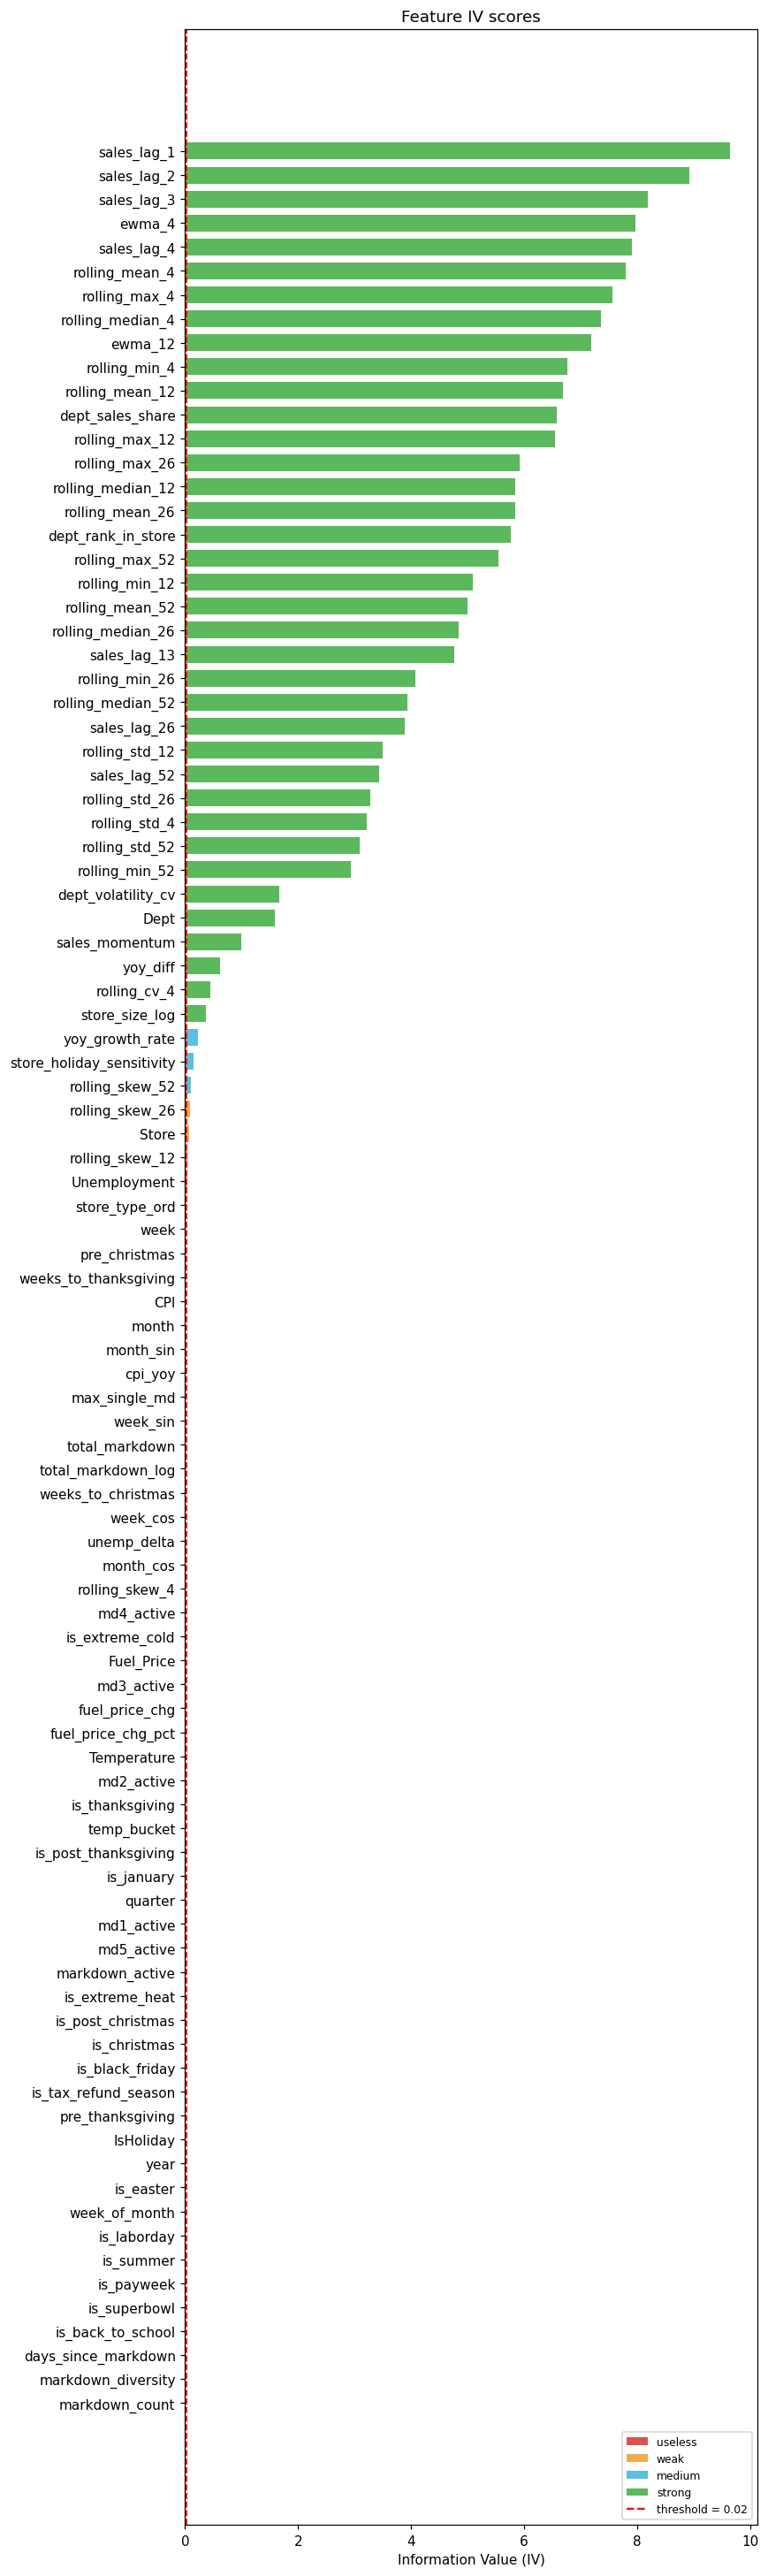

In [33]:
plot_iv(selector.iv_filter_, IV_THRESHOLD)

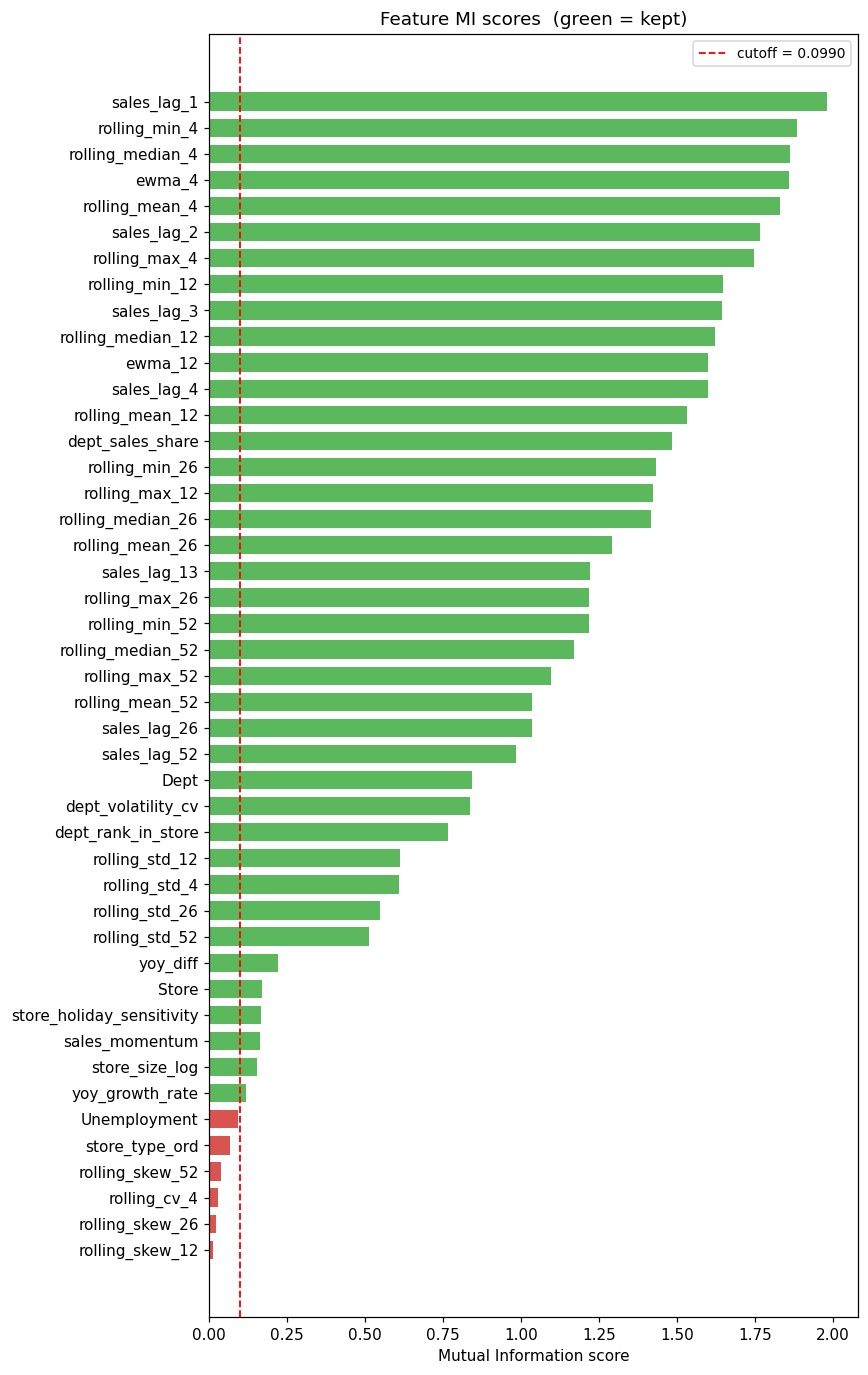

In [34]:
plot_mi(selector.mi_filter_, MI_THRESHOLD)

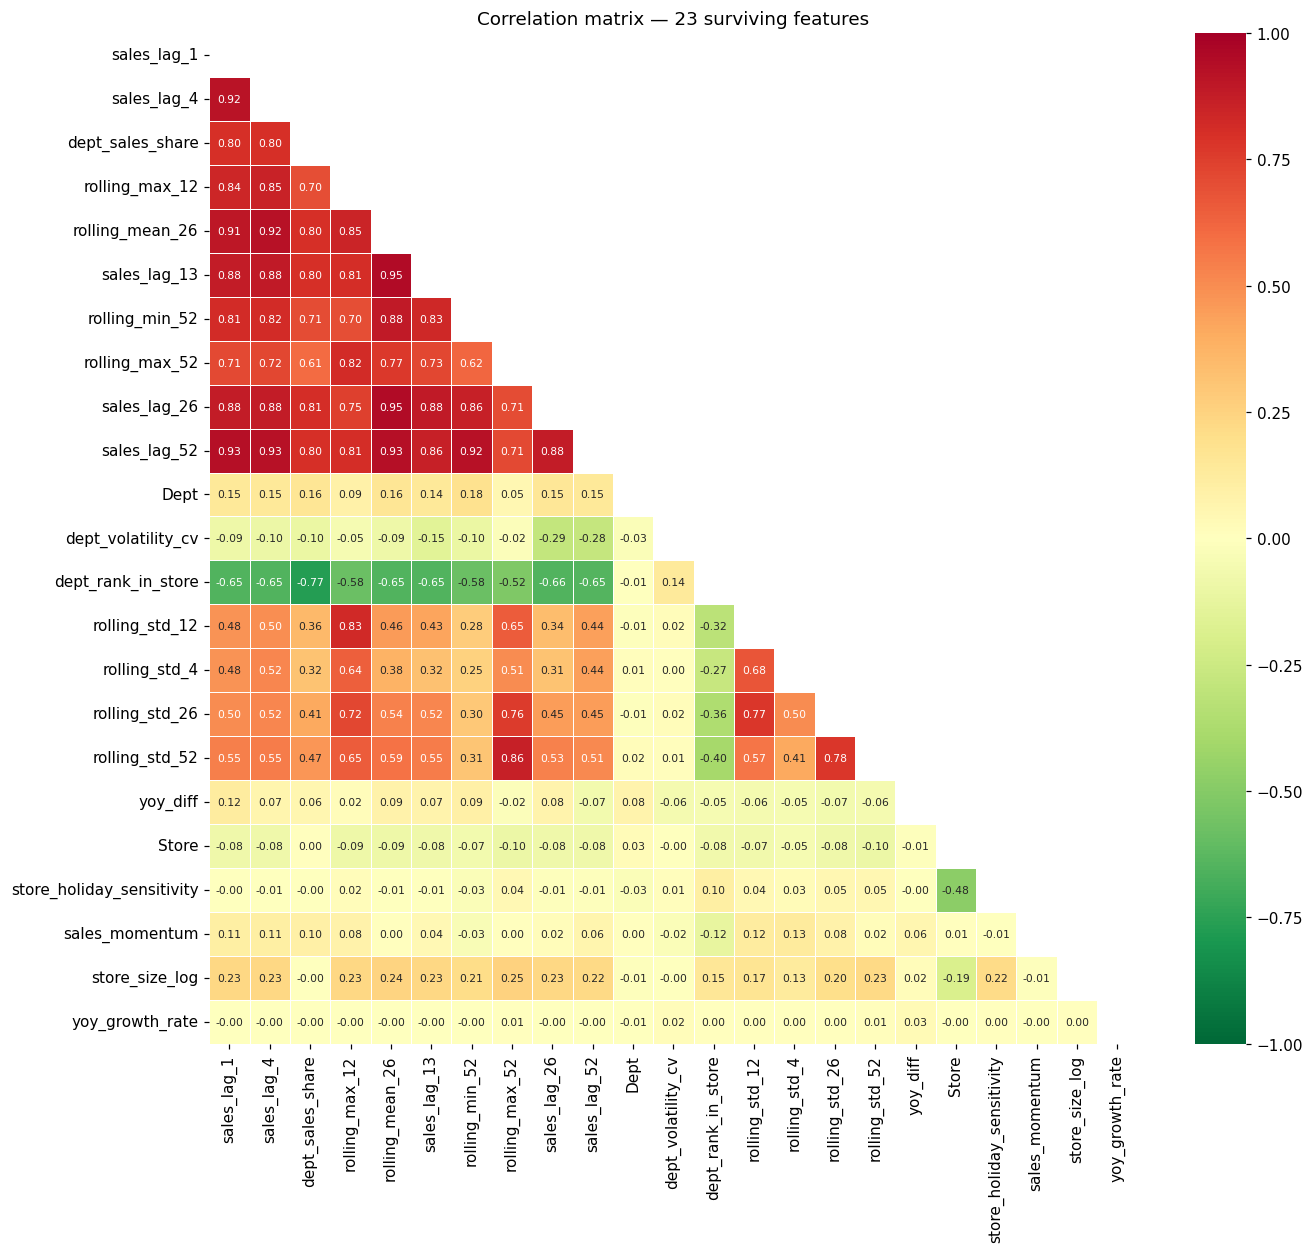

In [35]:
plot_corr_heatmap(X_train_final)

In [36]:
pairs = selector.corr_filter_.correlated_pairs()
if pairs.empty:
    print("No correlated pairs exceeded the threshold.")
else:
    display(pairs)

,feature_a,feature_b,correlation,kept,dropped
39,ewma_4,rolling_mean_4,0.9968,rolling_mean_4,ewma_4
95,ewma_12,rolling_mean_12,0.9964,rolling_mean_12,ewma_12
27,rolling_median_4,rolling_mean_4,0.9945,rolling_mean_4,rolling_median_4
26,rolling_median_4,ewma_4,0.9919,ewma_4,rolling_median_4
89,rolling_median_12,rolling_mean_12,0.9906,rolling_mean_12,rolling_median_12
...,...,...,...,...,...
59,rolling_mean_4,rolling_min_26,0.9036,rolling_min_26,rolling_mean_4
73,rolling_max_4,rolling_max_12,0.9032,rolling_max_12,rolling_max_4
15,rolling_min_4,rolling_max_4,0.9025,rolling_max_4,rolling_min_4
99,ewma_12,rolling_median_52,0.9024,rolling_median_52,ewma_12


In [37]:
print("Pipeline summary")
print("=" * 50)
print(f"  Stage 1  time features added : {len([c for c in df_full.columns if c not in df_merged.columns])}")
print(f"  Stage 2  features after row transforms : {X_train_df.shape[1]}")
print(f"  Stage 3  features after selection      : {X_train_final.shape[1]}")
print()
print(f"  Final X_train : {X_train_final.shape}")
print(f"  Final X_val   : {X_val_final.shape}")
print()
print("Kept features:")
for i, col in enumerate(X_train_final.columns, 1):
    print(f"  {i:2d}. {col}")

Pipeline summary
  Stage 1  time features added : 42
  Stage 2  features after row transforms : 95
  Stage 3  features after selection      : 23

  Final X_train : (332778, 23)
  Final X_val   : (88792, 23)

Kept features:
   1. sales_lag_1
   2. sales_lag_4
   3. dept_sales_share
   4. rolling_max_12
   5. rolling_mean_26
   6. sales_lag_13
   7. rolling_min_52
   8. rolling_max_52
   9. sales_lag_26
  10. sales_lag_52
  11. Dept
  12. dept_volatility_cv
  13. dept_rank_in_store
  14. rolling_std_12
  15. rolling_std_4
  16. rolling_std_26
  17. rolling_std_52
  18. yoy_diff
  19. Store
  20. store_holiday_sensitivity
  21. sales_momentum
  22. store_size_log
  23. yoy_growth_rate


# Training & Validation (LightGBM Hyperparameter Experiments)

In [38]:
# Install the libraries needed for gradient boosting and experiment tracking
!pip install -q lightgbm mlflow dagshub

import time
import lightgbm as lgb
import mlflow
import dagshub


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212

## Connect MLflow tracking to DagsHub

`dagshub.init` points every subsequent `mlflow.*` call at the MLflow server hosted on DagsHub, so runs created below become visible in the repo's "Experiments" tab instead of only living locally.

In [39]:
# Wire up MLflow so that all logging in this notebook is sent to DagsHub
# instead of a local mlruns/ folder.
dagshub.init(repo_owner='ikvas22', repo_name='Walmart-Recruiting---Store-Sales-Forecasting', mlflow=True)


❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=1ae254d4-e6f5-4aef-a73d-94a80e32e707&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=1bb68ab098d12ffee0935d0589132e98e5cd6b673e4660dc1b605398e0f4f1f5




Accessing as ntsuk22

Initialized MLflow to track repo "ikvas22/Walmart-Recruiting---Store-Sales-Forecasting"

Repository ikvas22/Walmart-Recruiting---Store-Sales-Forecasting initialized!

## Prepare training data and sample weights

In [40]:
# ── Sample weights for the competition metric (WMAE) ────────────
# Holiday weeks count 5x as much as regular weeks. We pass the same
# weights into LightGBM's `sample_weight` so the model is trained to
# pay extra attention to holiday weeks, not just scored on them.
train_weights = make_holiday_weights(df_train["IsHoliday"])
val_weights   = make_holiday_weights(df_val["IsHoliday"])

# Plain numpy arrays for LightGBM
X_train_arr = X_train_final.values
X_val_arr   = X_val_final.values

print(f"X_train_arr : {X_train_arr.shape}")
print(f"X_val_arr   : {X_val_arr.shape}")
print(f"y_train     : {y_train.shape}")
print(f"y_val       : {y_val.shape}")


X_train_arr : (332778, 23)
X_val_arr   : (88792, 23)
y_train     : (332778,)
y_val       : (88792,)


## Define 5 hyperparameter configurations to experiment with

Each configuration changes model complexity (`num_leaves`, `max_depth`), the learning speed / number of rounds (`learning_rate`, `n_estimators`), and the regularization via row/column subsampling.

In [41]:
# ── Hyperparameter grid ──────────────────────────────────────────
# Every dict below is one full LightGBM configuration tested end-to-end
# (train -> predict on validation -> score with WMAE -> log to MLflow).
EXPERIMENTS = [
    {
        "name": "exp1_baseline",
        "params": {
            "objective": "regression_l1",   # optimize MAE, closest to the WMAE target metric
            "num_leaves": 31,
            "learning_rate": 0.05,
            "n_estimators": 300,
            "max_depth": -1,
            "subsample": 1.0,
            "colsample_bytree": 1.0,
            "random_state": 42,
        },
    },
    {
        "name": "exp2_more_leaves",
        "params": {
            "objective": "regression_l1",
            "num_leaves": 63,               # more leaves -> higher model capacity
            "learning_rate": 0.05,
            "n_estimators": 300,
            "max_depth": -1,
            "subsample": 1.0,
            "colsample_bytree": 1.0,
            "random_state": 42,
        },
    },
    {
        "name": "exp3_slow_learning",
        "params": {
            "objective": "regression_l1",
            "num_leaves": 63,
            "learning_rate": 0.02,          # slower learning rate...
            "n_estimators": 800,            # ...compensated with more boosting rounds
            "max_depth": -1,
            "subsample": 1.0,
            "colsample_bytree": 1.0,
            "random_state": 42,
        },
    },
    {
        "name": "exp4_regularized",
        "params": {
            "objective": "regression_l1",
            "num_leaves": 63,
            "learning_rate": 0.05,
            "n_estimators": 400,
            "max_depth": 8,                 # capped depth
            "subsample": 0.8,               # row subsampling (bagging)
            "colsample_bytree": 0.8,        # feature subsampling
            "random_state": 42,
        },
    },
    {
        "name": "exp5_deep_fast",
        "params": {
            "objective": "regression_l1",
            "num_leaves": 127,              # high capacity
            "learning_rate": 0.1,           # faster learning...
            "n_estimators": 200,            # ...with fewer rounds
            "max_depth": 12,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "random_state": 42,
        },
    },
]

print(f"Prepared {len(EXPERIMENTS)} hyperparameter configurations to test.")


Prepared 5 hyperparameter configurations to test.


## Run all experiments, log each one to MLflow (DagsHub), and print results

In [42]:
# ── Training / validation loop ───────────────────────────────────
# For every configuration:
#   1. create/select a dedicated MLflow experiment on DagsHub
#   2. train a LightGBM regressor with sample weights on the train split
#   3. score train and validation with the competition WMAE metric
#   4. log parameters + metrics to MLflow
#   5. print the result immediately in this notebook (no external file)
results = []

for cfg in EXPERIMENTS:
    exp_name = cfg["name"]
    params   = cfg["params"]

    # Each experiment gets its own MLflow "experiment" bucket on DagsHub,
    # so results show up as separate experiments in the DagsHub UI.
    mlflow.set_experiment(exp_name)

    with mlflow.start_run(run_name=exp_name):
        start_time = time.time()

        model = lgb.LGBMRegressor(**params, verbose=-1)
        model.fit(
            X_train_arr,
            y_train,
            sample_weight=train_weights,
        )

        train_pred = model.predict(X_train_arr)
        val_pred   = model.predict(X_val_arr)

        train_wmae = wmae(y_train, train_pred, train_weights)
        val_wmae   = wmae(y_val,   val_pred,   val_weights)

        train_time = time.time() - start_time

        # Log hyperparameters and metrics to MLflow / DagsHub
        mlflow.log_params(params)
        mlflow.log_metric("train_wmae", train_wmae)
        mlflow.log_metric("val_wmae", val_wmae)
        mlflow.log_metric("train_time_sec", train_time)

        results.append({
            "experiment": exp_name,
            **params,
            "train_wmae": train_wmae,
            "val_wmae": val_wmae,
            "train_time_sec": train_time,
        })

        # Print the result of this experiment right away
        print(
            f"[{exp_name}] "
            f"num_leaves={params['num_leaves']:>3} | "
            f"lr={params['learning_rate']:<5} | "
            f"n_estimators={params['n_estimators']:<4} | "
            f"max_depth={params['max_depth']:<3} | "
            f"subsample={params['subsample']:<3} | "
            f"colsample={params['colsample_bytree']:<3} | "
            f"train_WMAE={train_wmae:,.2f} | "
            f"val_WMAE={val_wmae:,.2f} | "
            f"time={train_time:.1f}s"
        )

print("\nAll experiments finished and logged to MLflow (DagsHub).")


2026/07/06 09:56:40 INFO mlflow.tracking.fluent: Experiment with name 'exp1_baseline' does not exist. Creating a new experiment.


[exp1_baseline] num_leaves= 31 | lr=0.05  | n_estimators=300  | max_depth=-1  | subsample=1.0 | colsample=1.0 | train_WMAE=1,794.45 | val_WMAE=679.35 | time=67.2s
🏃 View run exp1_baseline at: https://dagshub.com/ikvas22/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/3/runs/4e840f828673488c803b879e8438074d
🧪 View experiment at: https://dagshub.com/ikvas22/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/3


2026/07/06 09:57:49 INFO mlflow.tracking.fluent: Experiment with name 'exp2_more_leaves' does not exist. Creating a new experiment.


[exp2_more_leaves] num_leaves= 63 | lr=0.05  | n_estimators=300  | max_depth=-1  | subsample=1.0 | colsample=1.0 | train_WMAE=1,517.97 | val_WMAE=437.04 | time=51.0s
🏃 View run exp2_more_leaves at: https://dagshub.com/ikvas22/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/4/runs/ce517c4614a143a1a37a22e115f146fd
🧪 View experiment at: https://dagshub.com/ikvas22/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/4


2026/07/06 09:58:42 INFO mlflow.tracking.fluent: Experiment with name 'exp3_slow_learning' does not exist. Creating a new experiment.


[exp3_slow_learning] num_leaves= 63 | lr=0.02  | n_estimators=800  | max_depth=-1  | subsample=1.0 | colsample=1.0 | train_WMAE=1,501.21 | val_WMAE=413.17 | time=146.0s
🏃 View run exp3_slow_learning at: https://dagshub.com/ikvas22/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/5/runs/650a6c3a790240dd8a63fd74df222a15
🧪 View experiment at: https://dagshub.com/ikvas22/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/5


2026/07/06 10:01:10 INFO mlflow.tracking.fluent: Experiment with name 'exp4_regularized' does not exist. Creating a new experiment.


[exp4_regularized] num_leaves= 63 | lr=0.05  | n_estimators=400  | max_depth=8   | subsample=0.8 | colsample=0.8 | train_WMAE=1,462.80 | val_WMAE=438.06 | time=61.9s
🏃 View run exp4_regularized at: https://dagshub.com/ikvas22/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/6/runs/e1a0bef867fd4db38090d6cfff38b15d
🧪 View experiment at: https://dagshub.com/ikvas22/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/6


2026/07/06 10:02:14 INFO mlflow.tracking.fluent: Experiment with name 'exp5_deep_fast' does not exist. Creating a new experiment.


[exp5_deep_fast] num_leaves=127 | lr=0.1   | n_estimators=200  | max_depth=12  | subsample=0.8 | colsample=0.8 | train_WMAE=1,381.24 | val_WMAE=420.95 | time=34.2s
🏃 View run exp5_deep_fast at: https://dagshub.com/ikvas22/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/7/runs/3eea6e44a94c4325b7ed08252185f518
🧪 View experiment at: https://dagshub.com/ikvas22/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/7

All experiments finished and logged to MLflow (DagsHub).


## Compare all experiments and report the best hyperparameters

In [43]:
# ── Summarize results and pick the best configuration ────────────
results_df = pd.DataFrame(results).sort_values("val_wmae").reset_index(drop=True)

print("Experiment results sorted by validation WMAE (lower is better):")
display(results_df[[
    "experiment", "num_leaves", "learning_rate", "n_estimators",
    "max_depth", "subsample", "colsample_bytree",
    "train_wmae", "val_wmae", "train_time_sec",
]])

best = results_df.iloc[0]
print("\nBest experiment based on validation WMAE:")
print(f"  Experiment name  : {best['experiment']}")
print(f"  num_leaves       : {best['num_leaves']}")
print(f"  learning_rate    : {best['learning_rate']}")
print(f"  n_estimators     : {best['n_estimators']}")
print(f"  max_depth        : {best['max_depth']}")
print(f"  subsample        : {best['subsample']}")
print(f"  colsample_bytree : {best['colsample_bytree']}")
print(f"  Train WMAE       : {best['train_wmae']:,.2f}")
print(f"  Validation WMAE  : {best['val_wmae']:,.2f}")


Experiment results sorted by validation WMAE (lower is better):


,experiment,num_leaves,learning_rate,n_estimators,max_depth,subsample,colsample_bytree,train_wmae,val_wmae,train_time_sec
0,exp3_slow_learning,63,0.0200,800,-1,1.0000,1.0000,"1,501.2050",413.1740,146.0409
1,exp5_deep_fast,127,0.1000,200,12,0.8000,0.8000,"1,381.2364",420.9484,34.1540
2,exp2_more_leaves,63,0.0500,300,-1,1.0000,1.0000,"1,517.9657",437.0445,51.0073
3,exp4_regularized,63,0.0500,400,8,0.8000,0.8000,"1,462.7985",438.0639,61.8920
4,exp1_baseline,31,0.0500,300,-1,1.0000,1.0000,"1,794.4486",679.3477,67.2488



Best experiment based on validation WMAE:
  Experiment name  : exp3_slow_learning
  num_leaves       : 63
  learning_rate    : 0.02
  n_estimators     : 800
  max_depth        : -1
  subsample        : 1.0
  colsample_bytree : 1.0
  Train WMAE       : 1,501.21
  Validation WMAE  : 413.17
